****
IMPORT
****

In [12]:
import mlflow
import os
import optuna

import mlflow.lightgbm

import pandas as pd
import numpy as np
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, make_scorer
from pathlib import Path

****
DATASET
****

In [2]:
df = pd.read_parquet("../data/processed/dataset_train_fusion.parquet")

****
Train V1
****

In [6]:
# --- CONFIGURATION ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
FN_COST = 10   # Coût d'un Faux Négatif (mauvais client non détecté)
FP_COST = 1    # Coût d'un Faux Positif (bon client refusé à tort)

TRACKING_DIR = Path("../data/mlflow").resolve()
TRACKING_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_NAME = "Credit_Scoring_Baseline"


# --- 1. SPLIT TRAIN/TEST ---
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print("Séparation Train / Test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Taille Train : {X_train.shape[0]} clients")
print(f"Taille Test  : {X_test.shape[0]} clients")


# --- 2. SCORE MÉTIER ---
def business_cost_function(y_true, y_pred, fn_cost=FN_COST, fp_cost=FP_COST):
    """Coût total = fn_cost * Faux Négatifs + fp_cost * Faux Positifs."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost

business_scorer = make_scorer(business_cost_function, greater_is_better=False)


# --- 3. SETUP MLFLOW (réutilisable pour les prochains runs) ---
def get_or_create_experiment(name: str, artifact_location: str) -> str:
    """Retourne l'ID de l'expérience, en la créant si besoin avec le bon artifact_location."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(name)
    if exp is None:
        return client.create_experiment(name, artifact_location=artifact_location)
    return exp.experiment_id

mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DIR}/metadata.db")
experiment_id = get_or_create_experiment(
    EXPERIMENT_NAME, artifact_location=f"file:{TRACKING_DIR}/mlruns"
)
mlflow.set_experiment(experiment_id=experiment_id)
mlflow.lightgbm.autolog()


# --- 4. ENTRAÎNEMENT ---
print("\nLancement de l'expérience MLflow avec LightGBM...")

with mlflow.start_run(run_name="LGBM_Baseline"):
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    cost = fn * FN_COST + fp * FP_COST

    # Paramètres métier (comparables entre runs si tu changes les pondérations)
    mlflow.log_params({"fn_cost": FN_COST, "fp_cost": FP_COST})

    # Toutes les métriques en un seul appel
    mlflow.log_metrics({
        "business_cost": cost,
        "test_auc": auc,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    })

    print("✅ Modèle entraîné et loggé !")
    print("📊 Résultats sur le jeu de test :")
    print(f"   - AUC Score   : {auc:.4f}")
    print(f"   - Accuracy    : {acc:.4f}")
    print(f"   - Coût Métier : {cost} pénalités (FN={fn}, FP={fp})")

Séparation Train / Test...
Taille Train : 246008 clients
Taille Test  : 61503 clients

Lancement de l'expérience MLflow avec LightGBM...


2026/08/10 21:33:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.258371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81180
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 573
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/08/10 21:33:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/10 21:33:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/

✅ Modèle entraîné et loggé !
📊 Résultats sur le jeu de test :
   - AUC Score   : 0.7830
   - Accuracy    : 0.7286
   - Coût Métier : 30650 pénalités (FN=1551, FP=15140)


`Observation`

- AUC => Très correct. Le modèle réussit bien à différencier les bons des mauvais profils. Notre préparation des données fonctionne.

- Accuracy => Faible, mais logique. En forçant le modèle à traquer la minorité de mauvais payeurs (class_weight='balanced'), on le rend volontairement "paranoïaque", ce qui fait chuter la précision globale.

- Coût Métier => Le vrai problème. Avec un seuil à 0.5, le modèle rejette à tort 15 140 excellents clients (manque à gagner) et laisse quand même passer 1 551 mauvais payeurs (pertes financières lourdes).

#### Conclusion : Le modèle est intelligent, mais son point de décision (0.5) est financièrement inadapté.

****
SEARCH SEUIL V1
****

🔍 Recherche du seuil optimal en cours...
✅ Terminé !
💰 Coût avec le seuil par défaut (0.5) : 30623
🏆 Coût MINIMUM trouvé            : 30433
🎯 MEILLEUR SEUIL À APPLIQUER      : 0.54


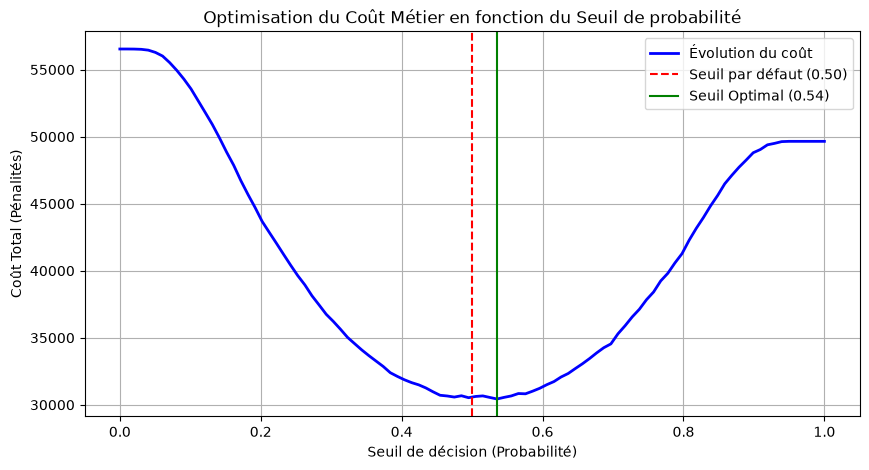

In [7]:
# 1. On récupère les probabilités déjà calculées par notre modèle sur le jeu de test
# (Assurez-vous que la cellule précédente a bien tourné et que y_pred_proba existe)
probabilites = y_pred_proba

# 2. On prépare des listes pour stocker nos résultats
seuils = np.linspace(0.0, 1.0, 100) # 100 seuils entre 0 et 1 (0.01, 0.02...)
couts_metier = []

# Variables pour retenir le meilleur scénario
meilleur_seuil = 0.5
cout_minimum = float('inf')

print("🔍 Recherche du seuil optimal en cours...")

# 3. La boucle d'optimisation
for seuil in seuils:
    # On crée nos propres prédictions : 1 si proba > seuil, sinon 0
    predictions_custom = (probabilites >= seuil).astype(int)
    
    # On calcule la matrice de confusion pour ce seuil précis
    tn, fp, fn, tp = confusion_matrix(y_test, predictions_custom).ravel()
    
    # On calcule le coût avec les pénalités de Michaël (FN = 10, FP = 1)
    cout = (fn * 10) + (fp * 1)
    couts_metier.append(cout)
    
    # Si c'est le coût le plus bas jamais vu, on sauvegarde le seuil
    if cout < cout_minimum:
        cout_minimum = cout
        meilleur_seuil = seuil

print(f"✅ Terminé !")
print(f"💰 Coût avec le seuil par défaut (0.5) : {couts_metier[50]}")
print(f"🏆 Coût MINIMUM trouvé            : {cout_minimum}")
print(f"🎯 MEILLEUR SEUIL À APPLIQUER      : {meilleur_seuil:.2f}")

# --- 4. PREUVE VISUELLE POUR LA SOUTENANCE ---
plt.figure(figsize=(10, 5))
plt.plot(seuils, couts_metier, label="Évolution du coût", color='blue', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil par défaut (0.50)")
plt.axvline(x=meilleur_seuil, color='green', linestyle='-', label=f"Seuil Optimal ({meilleur_seuil:.2f})")

plt.title("Optimisation du Coût Métier en fonction du Seuil de probabilité")
plt.xlabel("Seuil de décision (Probabilité)")
plt.ylabel("Coût Total (Pénalités)")
plt.legend()
plt.grid(True)
plt.show()

`Observation`
- Le seuil est très proche de celui par default ce qui améliore peu le coût metier.
- L'une des causes est peut-être le rééquilibrage mathématique par balanced durant le modèle qui fausse le resultat.

****
TRAIN V2
****

In [11]:
print("\n🚀 Lancement de l'expérience n°2 : Modèle naturel")

# On s'assure d'être dans la bonne expérience
mlflow.set_experiment(EXPERIMENT_NAME)

# On lance le Run
with mlflow.start_run(run_name="LGBM_Unbalanced"):
    
    # 1. Modèle SANS class_weight='balanced'
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # 2. Prédictions et Probabilités (seuil par défaut à 0.5)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 3. Calcul des métriques au seuil de 0.5
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    cout_default = (fn * FN_COST) + (fp * FP_COST)

    # 4. Enregistrement dans MLflow
    # On log explicitement qu'on n'a pas utilisé de class_weight
    mlflow.log_param("class_weight", "None") 
    
    mlflow.log_metrics({
        "business_cost_default": cout_default,
        "test_auc": auc,
        "test_accuracy": acc,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    })
    
    print(f"✅ Modèle entraîné et évalué au seuil de 0.5 !")
    print(f"📊 AUC Score : {auc:.4f}")
    print(f"📊 Accuracy  : {acc:.4f}")
    print(f"💰 Coût Métier : {cout_default} pénalités (FN={fn}, FP={fp})")


🚀 Lancement de l'expérience n°2 : Modèle naturel


2026/08/10 22:00:17 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.283503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81180
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 573
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


2026/08/10 22:00:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/10 22:00:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/

✅ Modèle entraîné et évalué au seuil de 0.5 !
📊 AUC Score : 0.7813
📊 Accuracy  : 0.9200
💰 Coût Métier : 47762 pénalités (FN=4760, FP=162)


`Observation`
- On constate que le accuray augmente, ce qui est logique avec notre déséquilibre, le modèle capture la prédominance des profils non risqués. On peut voir quel es faux positive on considérablement baissé au profil des faux negatifs qui on eu une croissance inverse.
- Le rééquilibrage balanced avait donc un bonne impact sur le resultat.

****
SEARCH SEUIL V2
****

🔍 Recherche du seuil optimal en cours...
✅ Terminé !
💰 Coût avec le seuil par défaut (0.5) : 47841
🏆 Coût MINIMUM trouvé            : 30508
🎯 MEILLEUR SEUIL À APPLIQUER      : 0.09


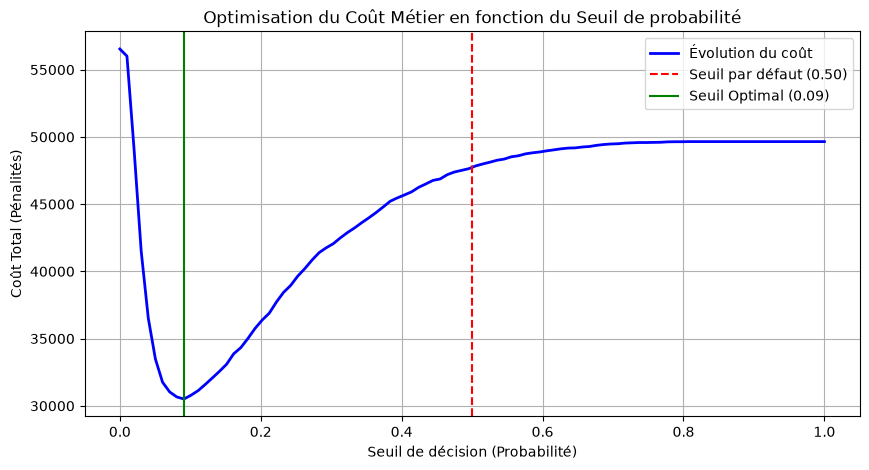

In [9]:
# 1. On récupère les probabilités déjà calculées par notre modèle sur le jeu de test
# (Assurez-vous que la cellule précédente a bien tourné et que y_pred_proba existe)
probabilites = y_pred_proba

# 2. On prépare des listes pour stocker nos résultats
seuils = np.linspace(0.0, 1.0, 100) # 100 seuils entre 0 et 1 (0.01, 0.02...)
couts_metier = []

# Variables pour retenir le meilleur scénario
meilleur_seuil = 0.5
cout_minimum = float('inf')

print("🔍 Recherche du seuil optimal en cours...")

# 3. La boucle d'optimisation
for seuil in seuils:
    # On crée nos propres prédictions : 1 si proba > seuil, sinon 0
    predictions_custom = (probabilites >= seuil).astype(int)
    
    # On calcule la matrice de confusion pour ce seuil précis
    tn, fp, fn, tp = confusion_matrix(y_test, predictions_custom).ravel()
    
    # On calcule le coût avec les pénalités de Michaël (FN = 10, FP = 1)
    cout = (fn * 10) + (fp * 1)
    couts_metier.append(cout)
    
    # Si c'est le coût le plus bas jamais vu, on sauvegarde le seuil
    if cout < cout_minimum:
        cout_minimum = cout
        meilleur_seuil = seuil

print(f"✅ Terminé !")
print(f"💰 Coût avec le seuil par défaut (0.5) : {couts_metier[50]}")
print(f"🏆 Coût MINIMUM trouvé            : {cout_minimum}")
print(f"🎯 MEILLEUR SEUIL À APPLIQUER      : {meilleur_seuil:.2f}")

# --- 4. PREUVE VISUELLE POUR LA SOUTENANCE ---
plt.figure(figsize=(10, 5))
plt.plot(seuils, couts_metier, label="Évolution du coût", color='blue', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil par défaut (0.50)")
plt.axvline(x=meilleur_seuil, color='green', linestyle='-', label=f"Seuil Optimal ({meilleur_seuil:.2f})")

plt.title("Optimisation du Coût Métier en fonction du Seuil de probabilité")
plt.xlabel("Seuil de décision (Probabilité)")
plt.ylabel("Coût Total (Pénalités)")
plt.legend()
plt.grid(True)
plt.show()

`Observation`
- Le seuil ici est plus proche de ce qui était attendu logiquement mais les résultats reste moins bon que sur le seuil du modèle balanced, même s l'ecart n'est pas astronomique (>100 coût).
- Le balanced avec donc bien un fort impact sur le resultat du seuil egalement, mais tout comme pour le modèle cela reste positif.

****
BEST HYPERPARAMS
****

In [14]:
print("\n🚀 Lancement de la recherche intelligente avec OPTUNA...")

# le temps qu'Optuna fasse ses 20 crash-tests.
mlflow.lightgbm.autolog(disable=True)

# On s'assure d'être dans la bonne expérience MLflow
mlflow.set_experiment(EXPERIMENT_NAME)

# --- 1. DÉFINITION DE L'OBJECTIF D'OPTUNA ---
def objective(trial):
    # Optuna choisit les paramètres intelligemment dans ces fourchettes
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "class_weight": "balanced", # On garde notre socle solide !
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    # Entraînement du modèle avec ces paramètres
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train, y_train)

    # Prédictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Recherche du meilleur seuil pour CE modèle précis
    seuils = np.linspace(0.0, 1.0, 100)
    cout_minimum = float('inf')

    for seuil in seuils:
        y_pred_custom = (y_pred_proba >= seuil).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()
        cout = (fn * FN_COST) + (fp * FP_COST) # (FN*10) + (FP*1)
        
        if cout < cout_minimum:
            cout_minimum = cout

    # On renvoie le coût minimum à Optuna (car son but est de minimiser cette valeur)
    return cout_minimum


# --- 2. LANCEMENT ET ENREGISTREMENT MLFLOW ---
with mlflow.start_run(run_name="Optuna_HyperTuning"):
    
    # On dit à Optuna qu'on veut "minimiser" le résultat (le coût)
    study = optuna.create_study(direction="minimize")
    
    # On lance 20 essais (tu pourras monter à 50 ou 100 plus tard pour un modèle parfait)
    study.optimize(objective, n_trials=20)

    # Récupération du grand gagnant
    meilleur_cout = study.best_value
    meilleurs_params = study.best_params
    
    # Enregistrement dans MLflow
    mlflow.log_params(meilleurs_params)
    mlflow.log_metric("min_business_cost", meilleur_cout)
    mlflow.log_param("tuning_framework", "Optuna")
    
    print("\n✅ OPTIMISATION TERMINÉE !")
    print(f"🏆 Coût Métier du modèle CHAMPION : {meilleur_cout} pénalités")
    print("⚙️ Paramètres de ce champion :")
    for key, value in meilleurs_params.items():
        print(f"   - {key}: {value}")

[I 2026-08-11 21:46:16,065] A new study created in memory with name: no-name-5f8b6ec8-68da-4ec2-9e20-6a3f7197fb66



🚀 Lancement de la recherche intelligente avec OPTUNA...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.259874 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81176
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 571
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[I 2026-08-11 21:46:31,637] Trial 0 finished with value: 31068.0 and parameters: {'n_estimators': 213, 'learning_rate': 0.017973748243579436, 'num_leaves': 50, 'max_depth': 8, 'min_child_samples': 58}. Best is trial 0 with value: 31068.0.


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.270747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81176
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 571
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[I 2026-08-11 21:46:42,142] Trial 1 finished with value: 30650.0 and parameters: {'n_estimators': 157, 'learning_rate': 0.1253509026250392, 'num_leaves': 54, 'max_depth': 13, 'min_child_samples': 60}. Best is trial 1 with value: 30650.0.


...

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.242768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81172
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 569
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[I 2026-08-11 21:50:22,971] Trial 18 finished with value: 31490.0 and parameters: {'n_estimators': 289, 'learning_rate': 0.18743347207844938, 'num_leaves': 43, 'max_depth': 11, 'min_child_samples': 88}. Best is trial 12 with value: 30070.0.


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.239933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81176
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 571
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[I 2026-08-11 21:50:35,766] Trial 19 finished with value: 30130.0 and parameters: {'n_estimators': 299, 'learning_rate': 0.08485474983415073, 'num_leaves': 30, 'max_depth': 14, 'min_child_samples': 46}. Best is trial 12 with value: 30070.0.



✅ OPTIMISATION TERMINÉE !
🏆 Coût Métier du modèle CHAMPION : 30070.0 pénalités
⚙️ Paramètres de ce champion :
   - n_estimators: 299
   - learning_rate: 0.06019063295463222
   - num_leaves: 26
   - max_depth: 15
   - min_child_samples: 78


`Observation`
- L'optimisation bayésienne avec Optuna a permis de faire descendre le coût métier à 30 070 pénalités (contre 30 433 pénalités pour le modèle équilibré par défaut, soit un gain de 363 points). Les paramètres retenus par le champion sont : n_estimators = 299, learning_rate ≈ 0.06, num_leaves = 26, max_depth = 15 et min_child_samples = 78.

`Interprétation`
- Optuna a favorisé un modèle avec un grand nombre d'arbres (299) mais une structure d'arbre relativement simple et contrainte (num_leaves = 26 pour une profondeur max de 15). Associé à un pas d'apprentissage plus prudent (0.06), ce réglage permet à l'algorithme d'affiner ses règles de décision progressivement tout en évitant le surapprentissage (overfitting).

****
FINALY TRAINING
****


🚀 Lancement de l'entraînement du Modèle Champion...


2026/08/11 22:05:03 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.257102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81172
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 569
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/08/11 22:05:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/11 22:05:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/


✅ ENTRAÎNEMENT DU CHAMPION TERMINÉ ET SAUVEGARDÉ DANS MLFLOW !
📊 AUC Score Final : 0.7853
🎯 Seuil Optimal appliqué : 0.54
💰 Coût Métier Final : 30070 pénalités (FN=1775, FP=12320)


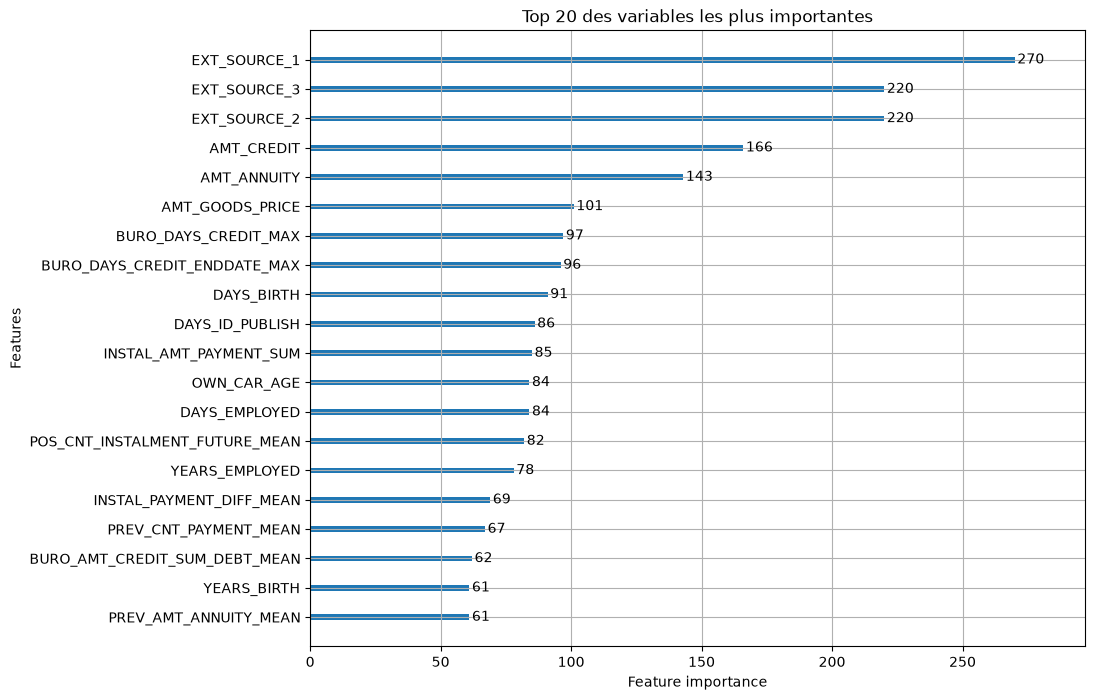

In [15]:
print("\n🚀 Lancement de l'entraînement du Modèle Champion...")

# 1. On réactive l'autolog pour que MLflow sauvegarde TOUT (modèle, hyperparamètres, feature_importance)
mlflow.lightgbm.autolog(disable=False)

# On se place dans l'expérience finale
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="LGBM_Champion_Final"):
    
    # 2. On instancie LightGBM avec EXACTEMENT les paramètres trouvés par Optuna
    model_champion = lgb.LGBMClassifier(
        n_estimators=299,
        learning_rate=0.06019063295463222,
        num_leaves=26,
        max_depth=15,
        min_child_samples=78,
        class_weight="balanced", # On garde notre socle
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # Entraînement
    model_champion.fit(X_train, y_train)
    
    # 3. Prédictions
    y_pred_proba = model_champion.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # 4. On recherche le seuil optimal EXACT de ce champion
    seuils = np.linspace(0.0, 1.0, 100)
    cout_minimum = float('inf')
    meilleur_seuil = 0.5
    meilleur_fn, meilleur_fp = 0, 0
    
    for seuil in seuils:
        y_pred_custom = (y_pred_proba >= seuil).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()
        cout = (fn * FN_COST) + (fp * FP_COST)
        
        if cout < cout_minimum:
            cout_minimum = cout
            meilleur_seuil = seuil
            meilleur_fn = fn
            meilleur_fp = fp

    # On recalcule les métriques finales avec le meilleur seuil
    y_pred_final = (y_pred_proba >= meilleur_seuil).astype(int)
    acc = accuracy_score(y_test, y_pred_final)

    # 5. On log les résultats finaux spécifiques au seuil
    mlflow.log_metric("optimal_threshold", meilleur_seuil)
    mlflow.log_metric("final_business_cost", cout_minimum)
    mlflow.log_metric("final_false_negatives", meilleur_fn)
    mlflow.log_metric("final_false_positives", meilleur_fp)
    mlflow.log_metric("final_accuracy_at_threshold", acc)
    
    print("\n✅ ENTRAÎNEMENT DU CHAMPION TERMINÉ ET SAUVEGARDÉ DANS MLFLOW !")
    print(f"📊 AUC Score Final : {auc:.4f}")
    print(f"🎯 Seuil Optimal appliqué : {meilleur_seuil:.2f}")
    print(f"💰 Coût Métier Final : {cout_minimum} pénalités (FN={meilleur_fn}, FP={meilleur_fp})")

    # Bonus pour la soutenance : Feature Importance
    lgb.plot_importance(model_champion, max_num_features=20, figsize=(10, 8), title="Top 20 des variables les plus importantes")
    plt.show()

`Observation`
- Le réentraînement final du modèle Champion donne un score AUC de 0.7853, un seuil optimal fixé à 0.54 et confirme le coût métier minimum de 30 070 pénalités (décomposé en 1 775 Faux Négatifs et 12 320 Faux Positifs). Le graphique d'importance des variables montre une nette prédominance des indicateurs financiers globaux et des évaluations de risque externes.

`Interprétation`
- Pouvoir discriminant (AUC 0.7853) : C'est notre meilleur score AUC depuis le début du projet, prouvant que l'optimisation des hyperparamètres a renforcé la capacité globale du modèle à ordonner les profils du plus risqué au moins risqué.
- Le coût metier le plus bas à était obtenu princiapelement avec une forte diminution des faux positifs (15 140 à 12 320) et ceux malgré un légère augmentation des faux negatif (1551 à 1775)
- L'analyse des variables les plus importantes montre que le modèle s'appuie principalement sur des indicateurs de solvabilité fondamentaux (scores externes EXT_SOURCE_..., ratios annuité/revenu, âge du client, durées d'engagement). Le modèle fonde donc ses décisions sur une logique financière cohérente et non sur des artéfacts statistiques.